In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

### Step-1 Import Dataset

In [50]:
df = pd.read_csv('ml_data_salary.csv')
df.head()

,age,distance,YearsExperience,Salary
0,31.1,77.75,1.1,39343
1,31.3,78.25,1.3,46205
2,31.5,78.75,1.5,37731
3,32.0,80.00,2.0,43525
4,32.2,80.50,2.2,39891


In [51]:
df.columns

Index(['age', 'distance', 'YearsExperience', 'Salary'], dtype='str')

### Step-2 Splitting dataset into training data and testing data

In [52]:
X = df[['YearsExperience']]
y = df['Salary']

In [53]:
X.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


In [54]:
y.head()

0    39343
1    46205
2    37731
3    43525
4    39891
Name: Salary, dtype: int64

In [55]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

### Step 3. Fit Linear Regression Mdel

In [56]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.532e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


### Step 4. Plotting

Text(0, 0.5, 'Salary')

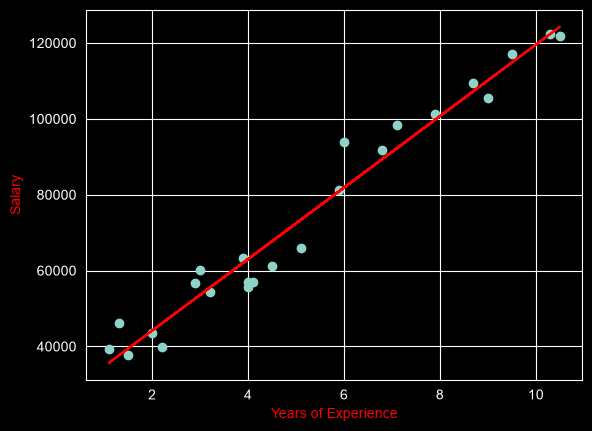

In [57]:
plt.scatter(X_train, y_train)
plt.plot(X_train, lr_model.predict(X_train), color = 'red')
plt.xlabel('Years of Experience', color = 'red')
plt.ylabel('Salary', color = 'red')

Text(0, 0.5, 'Salary')

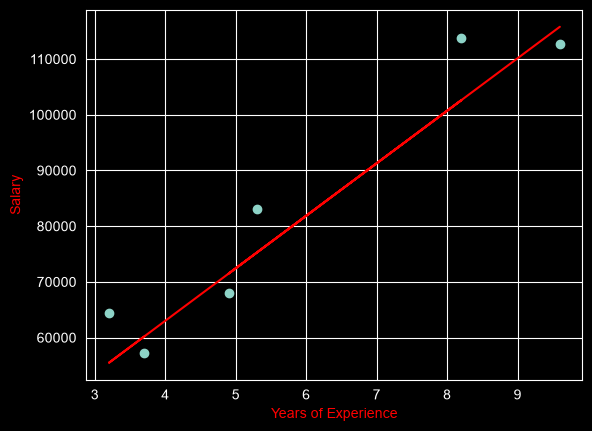

In [58]:
plt.scatter(X_test, y_test)
plt.plot(X_test, lr_model.predict(X_test), color = 'red')
plt.xlabel('Years of Experience', color = 'red')
plt.ylabel('Salary', color = 'red')

### Step 5. Evaluating the model

In [59]:
# Model score
print('Testing data score:',lr_model.score(X_test,y_test)*100)
print('Training data score:',lr_model.score(X_train,y_train)*100)

Testing data score: 90.24461774180497
Training data score: 96.45401573418147


### Step - 6 Prediction of Unknown Values

In [60]:
print(lr_model.predict([[10]]))

[119559.73624209]


In [61]:
lr_model.predict(X_test)

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

In [62]:
print(lr_model.predict([[5],[10],[20]]))

[ 72440.65962693 119559.73624209 213797.8894724 ]


In [63]:
x = ([5],[10],[20],[30])
lr_model.predict(x)

array([ 72440.65962693, 119559.73624209, 213797.8894724 , 308036.04270271])

In [64]:
x2 = ([1.1],[2.5],[3.2],[4.6])
lr_model.predict(x)

array([ 72440.65962693, 119559.73624209, 213797.8894724 , 308036.04270271])